# IT2011 — 2026-Y2-S1-KU-02
# Member 6: Gamage G.D.S.S. (IT25100147)
## Technique: Dimension Reduction (PCA)

**Why it's needed for this dataset:** Even after removing near-constant border pixels, the remaining feature
space is still large and highly correlated — neighboring pixels tend to be either both ink or both background
together. PCA compresses this correlated pixel space into a much smaller set of uncorrelated components while
retaining most of the variance, speeding up training and helping visualize class separability.


## Setup

This notebook is self-contained: it loads MNIST itself and reproduces any minimal prerequisite steps from a
teammate's earlier pipeline stage (noted where relevant).

In [ ]:

# Install TensorFlow if it is not already available in the current Python environment.
# This ensures that the required TensorFlow/Keras libraries are available when the notebook
# is shared and executed on another computer or in a different Python environment.
%pip install tensorflow

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from tensorflow.keras.datasets import mnist

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Training images:", X_train.shape, "| Training labels:", y_train.shape)
print("Test images:    ", X_test.shape,  "| Test labels:    ", y_test.shape)


Training images: (60000, 28, 28) | Training labels: (60000,)
Test images:     (10000, 28, 28) | Test labels:     (10000,)


*Prerequisite (reproducing normalization and feature selection minimally, so this
notebook is self-contained):*


In [2]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

X_train_norm = X_train.astype('float32') / 255.0
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)

selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train_flat)
print("Feature count after variance-threshold selection:", X_train_selected.shape[1])


Feature count after variance-threshold selection: 444


In [3]:
sample_size = 5000
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X_train_selected.shape[0], sample_size, replace=False)

X_sample = X_train_selected[sample_idx]
y_sample = y_train[sample_idx]

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_sample)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

print(f"Original feature count: {X_train_selected.shape[1]}")
print(f"Components needed to explain 95% of variance: {n_components_95}")


Original feature count: 444
Components needed to explain 95% of variance: 139


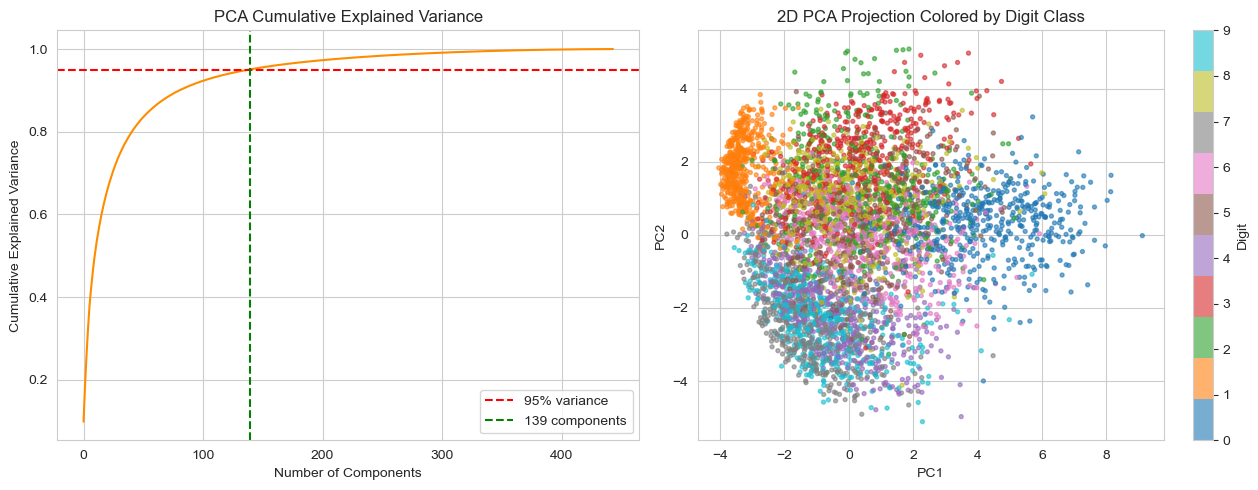

In [4]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(cumulative_variance, color='darkorange')
axes[0].axhline(0.95, color='red', linestyle='--', label='95% variance')
axes[0].axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} components')
axes[0].set_title("PCA Cumulative Explained Variance")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].legend()

scatter = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_sample, cmap='tab10', s=8, alpha=0.6)
axes[1].set_title("2D PCA Projection Colored by Digit Class")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(scatter, ax=axes[1], label='Digit')

plt.tight_layout()
plt.savefig('../results/eda_visualizations/06_pca_dimension_reduction.png', bbox_inches='tight')
plt.show()


**Interpretation:** A large majority of the pixel space's variance is captured by well under a hundred
components (see the printed count above), a substantial reduction from the original feature count. The 2D
projection shows several digits (e.g. 0 and 1) forming fairly distinct clusters, while others (e.g. 4/9, 3/5/8)
overlap. This overlap is a property of this specific 2-component *linear* projection (PCA maximizes variance,
not class separability -- that's what LDA is for) computed on a data sample, so it's a reasonable early
*hypothesis* about which digit pairs might be harder to separate, not a guarantee: the actual models will use
many more PCA components (for the SVM) or the raw pixel grid directly (for the CNN), and can exploit nonlinear
structure this 2D view can't capture. Worth cross-checking against the confusion matrix at the evaluation stage
rather than treating this as already confirmed.

